In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

RISK_PATH = "../data/processed/risk_scores.csv"

risk_df = pd.read_csv(RISK_PATH)

print("Risk data loaded successfully!")
print("Shape:", risk_df.shape)
print("\nColumns:")
print(risk_df.columns.tolist())

display(risk_df.head())

Risk data loaded successfully!
Shape: (9279, 18)

Columns:
['activity_id', 'project_id', 'phase', 'resource_type', 'activity_name', 'delay_prediction_days', 'delay_probability', 'total_float', 'criticality_weight', 'float_impact', 'risk_score', 'computed_critical', 'ES', 'EF', 'LS', 'LF', 'risk_rank', 'risk_percentile']


,activity_id,project_id,phase,resource_type,activity_name,delay_prediction_days,delay_probability,total_float,criticality_weight,float_impact,risk_score,computed_critical,ES,EF,LS,LF,risk_rank,risk_percentile
0,P00001_A0021,P00001,Foundation,labour,PCC,37.659949,1.0,0.0,1.0,1.0,1.0,1,107.0,116.0,107.0,116.0,1,99.105507
1,P00001_A0055,P00001,Structural Frame,labour,Slab Concrete,36.650922,1.0,0.0,1.0,1.0,1.0,1,204.0,211.0,204.0,211.0,2,99.105507
2,P00002_A0001,P00002,Preconstruction,management,Procurement Planning,35.804153,1.0,0.0,1.0,1.0,1.0,1,0.0,14.0,0.0,14.0,3,99.105507
3,P00002_A0081,P00002,Commissioning,labour,Testing,34.711766,1.0,0.0,1.0,1.0,1.0,1,315.0,329.0,315.0,329.0,4,99.105507
4,P00003_A0011,P00003,Earthwork,equipment,Excavation,34.658973,1.0,0.0,1.0,1.0,1.0,1,43.0,64.0,43.0,64.0,5,99.105507


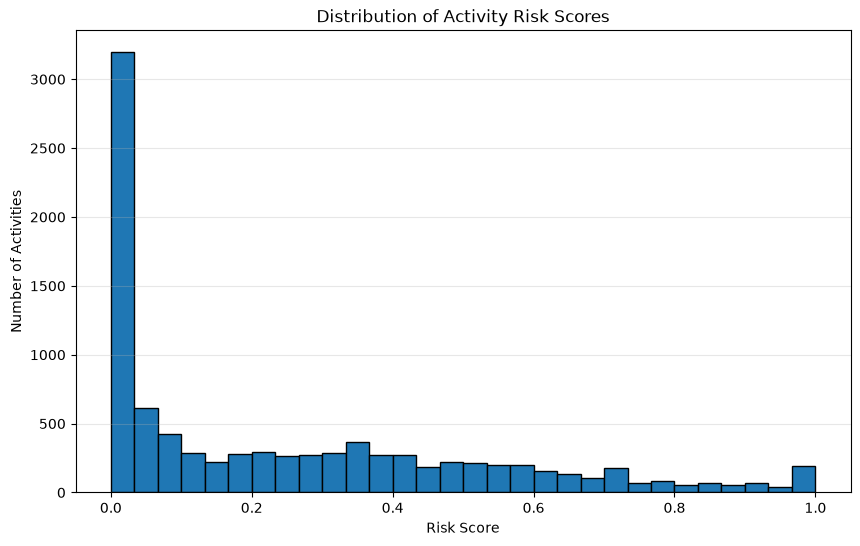

In [2]:
plt.figure(figsize=(10, 6))

plt.hist(
    risk_df["risk_score"],
    bins=30,
    edgecolor="black"
)

plt.xlabel("Risk Score")
plt.ylabel("Number of Activities")
plt.title("Distribution of Activity Risk Scores")
plt.grid(axis="y", alpha=0.3)

plt.show()

In [3]:
# Calculate risk thresholds
high_risk_threshold = risk_df["risk_score"].quantile(0.75)
critical_risk_threshold = risk_df["risk_score"].quantile(0.95)

high_risk_count = (risk_df["risk_score"] > high_risk_threshold).sum()
critical_risk_count = (risk_df["risk_score"] > critical_risk_threshold).sum()
normal_risk_count = len(risk_df) - high_risk_count

print(f"75th percentile risk threshold: {high_risk_threshold:.4f}")
print(f"95th percentile risk threshold: {critical_risk_threshold:.4f}")
print()
print(f"Total activities: {len(risk_df)}")
print(f"Normal/medium-risk activities: {normal_risk_count}")
print(f"High-risk activities: {high_risk_count}")
print(f"Critical-risk activities: {critical_risk_count}")

75th percentile risk threshold: 0.4199
95th percentile risk threshold: 0.8114

Total activities: 9279
Normal/medium-risk activities: 6959
High-risk activities: 2320
Critical-risk activities: 464


In [4]:
# Create risk categories

def classify_risk(score):
    if score > critical_risk_threshold:
        return "Critical Risk"
    elif score > high_risk_threshold:
        return "High Risk"
    else:
        return "Normal/Medium Risk"

risk_df["risk_category"] = risk_df["risk_score"].apply(classify_risk)

risk_counts = risk_df["risk_category"].value_counts()

display(risk_counts.to_frame("Activity Count"))

,Activity Count
risk_category,
Normal/Medium Risk,6959
High Risk,1856
Critical Risk,464


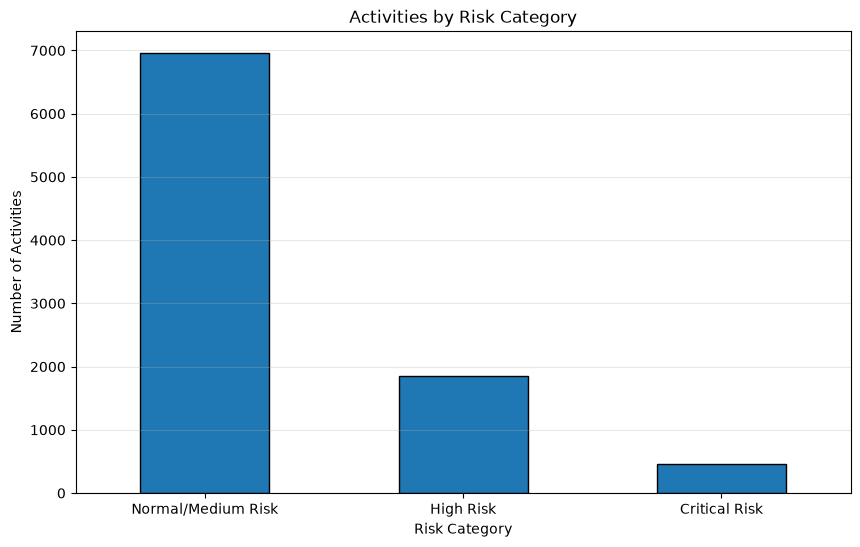

In [5]:
risk_counts.plot(
    kind="bar",
    figsize=(10, 6),
    edgecolor="black"
)

plt.xlabel("Risk Category")
plt.ylabel("Number of Activities")
plt.title("Activities by Risk Category")
plt.xticks(rotation=0)
plt.grid(axis="y", alpha=0.3)

plt.show()

In [6]:
# Top 20 highest-risk activities

top_20_risk = (
    risk_df
    .sort_values("risk_score", ascending=False)
    .head(20)
    [
        [
            "risk_rank",
            "activity_id",
            "project_id",
            "phase",
            "resource_type",
            "delay_prediction_days",
            "delay_probability",
            "criticality_weight",
            "float_impact",
            "risk_score"
        ]
    ]
)

display(top_20_risk)

,risk_rank,activity_id,project_id,phase,resource_type,delay_prediction_days,delay_probability,criticality_weight,float_impact,risk_score
0,1,P00001_A0021,P00001,Foundation,labour,37.659949,1.0,1.0,1.0,1.0
1,2,P00001_A0055,P00001,Structural Frame,labour,36.650922,1.0,1.0,1.0,1.0
2,3,P00002_A0001,P00002,Preconstruction,management,35.804153,1.0,1.0,1.0,1.0
3,4,P00002_A0081,P00002,Commissioning,labour,34.711766,1.0,1.0,1.0,1.0
4,5,P00003_A0011,P00003,Earthwork,equipment,34.658973,1.0,1.0,1.0,1.0
5,6,P00003_A0013,P00003,Earthwork,equipment,38.608501,1.0,1.0,1.0,1.0
6,7,P00003_A0059,P00003,Masonry,labour,43.496379,1.0,1.0,1.0,1.0
7,8,P00003_A0073,P00003,MEP,labour,37.945142,1.0,1.0,1.0,1.0
8,9,P00005_A0019,P00005,Foundation,labour,38.723610,1.0,1.0,1.0,1.0
9,10,P00005_A0079,P00005,External Works,equipment,39.034124,1.0,1.0,1.0,1.0


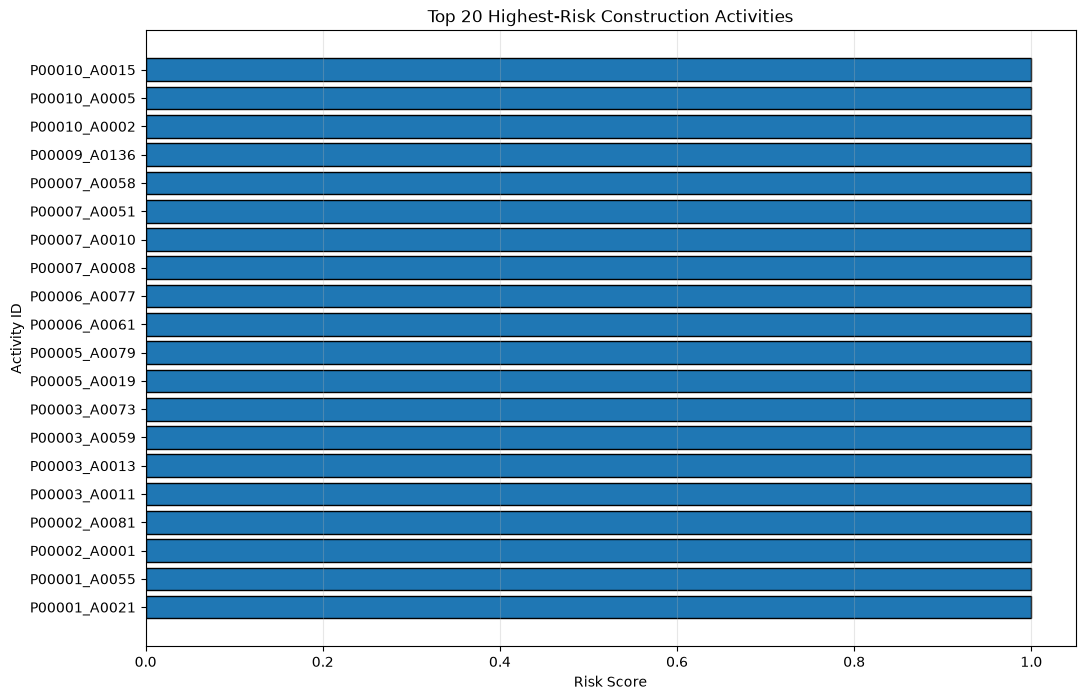

In [7]:
top_20_plot = (
    risk_df
    .sort_values("risk_score", ascending=False)
    .head(20)
    .sort_values("risk_score")
)

plt.figure(figsize=(12, 8))

plt.barh(
    top_20_plot["activity_id"],
    top_20_plot["risk_score"],
    edgecolor="black"
)

plt.xlabel("Risk Score")
plt.ylabel("Activity ID")
plt.title("Top 20 Highest-Risk Construction Activities")
plt.grid(axis="x", alpha=0.3)

plt.show()

In [8]:
# Risk analysis by construction phase

phase_risk = (
    risk_df
    .groupby("phase")
    .agg(
        activity_count=("activity_id", "count"),
        average_risk=("risk_score", "mean"),
        maximum_risk=("risk_score", "max"),
        average_delay=("delay_prediction_days", "mean")
    )
    .sort_values("average_risk", ascending=False)
)

display(phase_risk)

,activity_count,average_risk,maximum_risk,average_delay
phase,,,,
Preconstruction,374,0.461318,1.0,17.985037
Commissioning,315,0.406418,1.0,18.745746
Site Preparation,460,0.372367,1.0,17.499054
External Works,374,0.327857,1.0,17.560188
Earthwork,741,0.317872,1.0,16.805992
Foundation,1111,0.264812,1.0,16.474570
MEP,1111,0.245198,1.0,17.656613
Finishing,1383,0.208120,1.0,17.113784
Masonry,1111,0.200186,1.0,16.829821


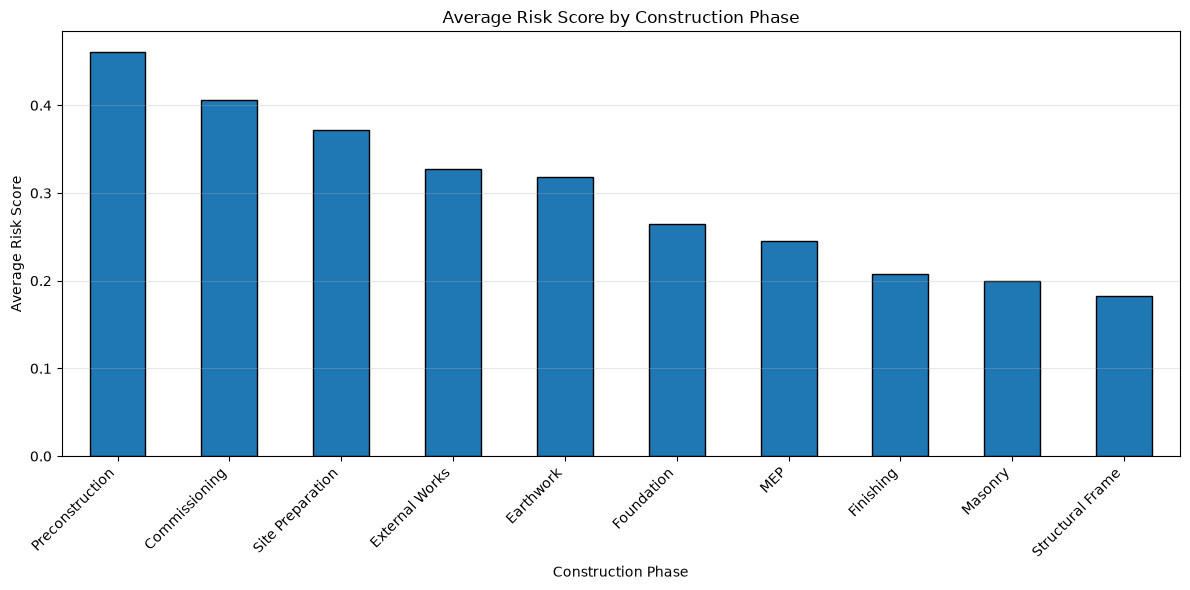

In [9]:
plt.figure(figsize=(12, 6))

phase_risk["average_risk"].plot(
    kind="bar",
    edgecolor="black"
)

plt.xlabel("Construction Phase")
plt.ylabel("Average Risk Score")
plt.title("Average Risk Score by Construction Phase")
plt.xticks(rotation=45, ha="right")
plt.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

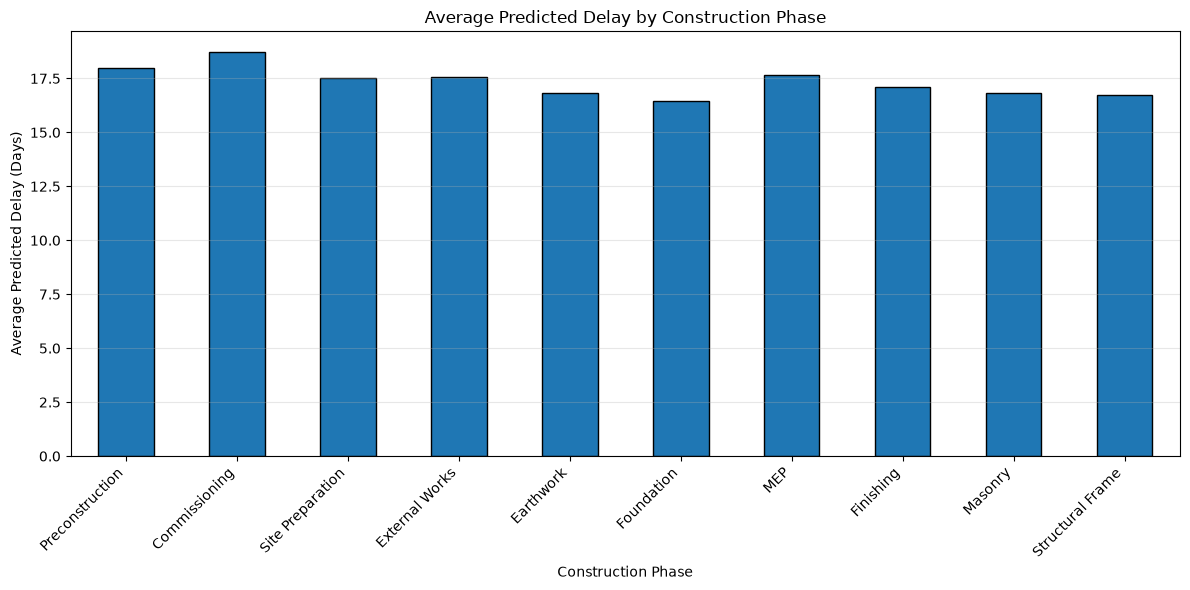

In [10]:
plt.figure(figsize=(12, 6))

phase_risk["average_delay"].plot(
    kind="bar",
    edgecolor="black"
)

plt.xlabel("Construction Phase")
plt.ylabel("Average Predicted Delay (Days)")
plt.title("Average Predicted Delay by Construction Phase")
plt.xticks(rotation=45, ha="right")
plt.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

In [13]:
cpm_df = pd.read_csv("../data/processed/cpm/activity_cpm_results.csv")

print("CPM columns:")
for i, column in enumerate(cpm_df.columns):
    print(i, ":", column)

print("\nFirst 5 rows:")
display(cpm_df.head())

CPM columns:
0 : project_id
1 : activity_id
2 : duration
3 : ES
4 : EF
5 : LS
6 : LF
7 : total_float
8 : computed_critical

First 5 rows:


,project_id,activity_id,duration,ES,EF,LS,LF,total_float,computed_critical
0,P00001,P00001_A0001,26,0.0,26.0,0.0,26.0,0.0,1
1,P00001,P00001_A0002,20,28.0,48.0,28.0,48.0,0.0,1
2,P00001,P00001_A0003,29,28.0,57.0,28.0,57.0,0.0,1
3,P00001,P00001_A0004,25,57.0,82.0,57.0,82.0,0.0,1
4,P00001,P00001_A0005,13,57.0,70.0,57.0,70.0,0.0,1


In [14]:
# Merge CPM critical-path information with risk scores

critical_info = cpm_df[
    ["activity_id", "computed_critical"]
].copy()

# Remove existing column if present
risk_df = risk_df.drop(
    columns=["computed_critical"],
    errors="ignore"
)

# Merge
risk_df = risk_df.merge(
    critical_info,
    on="activity_id",
    how="left"
)

print("Critical-path information merged successfully!")
print(
    "Missing values:",
    risk_df["computed_critical"].isna().sum()
)

# Critical vs non-critical analysis
critical_risk = (
    risk_df
    .groupby("computed_critical")
    .agg(
        activity_count=("activity_id", "count"),
        average_risk=("risk_score", "mean"),
        maximum_risk=("risk_score", "max"),
        average_delay=("delay_prediction_days", "mean")
    )
)

display(critical_risk)

Critical-path information merged successfully!
Missing values: 0


,activity_count,average_risk,maximum_risk,average_delay
computed_critical,,,,
0,6126,0.126049,0.9,16.972581
1,3153,0.493371,1.0,17.281811


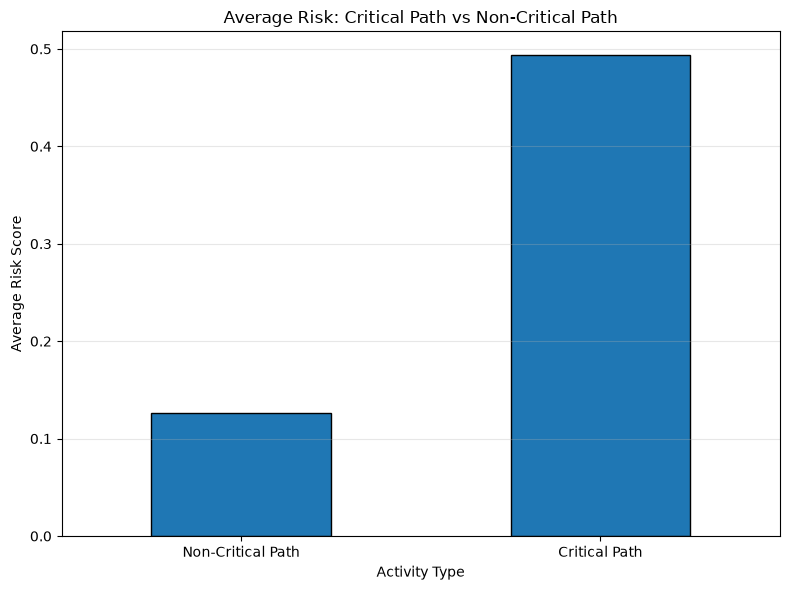

In [15]:
# Prepare labels for the chart

critical_risk_plot = critical_risk.copy()

critical_risk_plot.index = critical_risk_plot.index.map({
    0: "Non-Critical Path",
    1: "Critical Path",
    False: "Non-Critical Path",
    True: "Critical Path"
})

plt.figure(figsize=(8, 6))

critical_risk_plot["average_risk"].plot(
    kind="bar",
    edgecolor="black"
)

plt.xlabel("Activity Type")
plt.ylabel("Average Risk Score")
plt.title("Average Risk: Critical Path vs Non-Critical Path")
plt.xticks(rotation=0)
plt.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

In [16]:
critical_info = cpm_df[
    ["activity_id", "computed_critical"]
].copy()

risk_df = risk_df.drop(
    columns=["computed_critical"],
    errors="ignore"
)

risk_df = risk_df.merge(
    critical_info,
    on="activity_id",
    how="left"
)

print("Critical-path information merged successfully!")
print(
    "Missing values:",
    risk_df["computed_critical"].isna().sum()
)

critical_risk = (
    risk_df
    .groupby("computed_critical")
    .agg(
        activity_count=("activity_id", "count"),
        average_risk=("risk_score", "mean"),
        maximum_risk=("risk_score", "max"),
        average_delay=("delay_prediction_days", "mean")
    )
)

display(critical_risk)

Critical-path information merged successfully!
Missing values: 0


,activity_count,average_risk,maximum_risk,average_delay
computed_critical,,,,
0,6126,0.126049,0.9,16.972581
1,3153,0.493371,1.0,17.281811


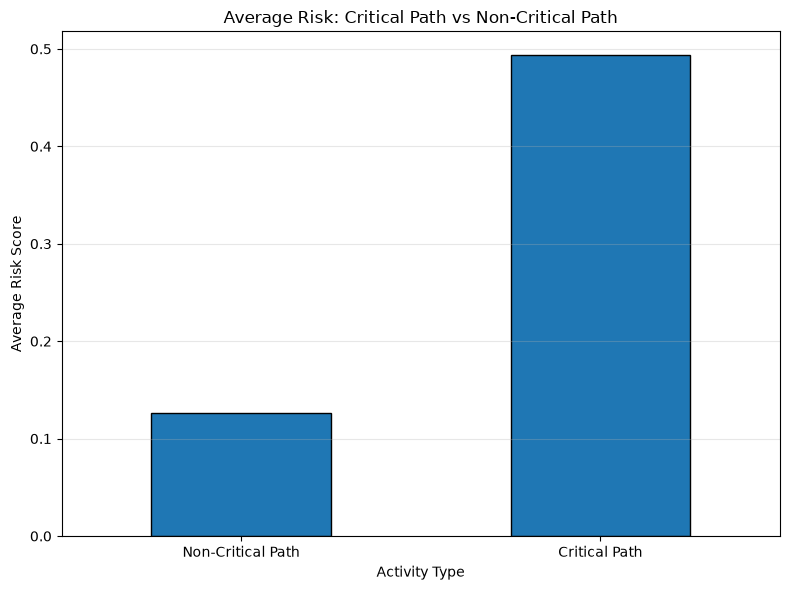

In [17]:
# Prepare labels for visualization

critical_risk_plot = critical_risk.copy()

critical_risk_plot.index = critical_risk_plot.index.map({
    0: "Non-Critical Path",
    1: "Critical Path"
})

plt.figure(figsize=(8, 6))

critical_risk_plot["average_risk"].plot(
    kind="bar",
    edgecolor="black"
)

plt.xlabel("Activity Type")
plt.ylabel("Average Risk Score")
plt.title("Average Risk: Critical Path vs Non-Critical Path")
plt.xticks(rotation=0)
plt.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

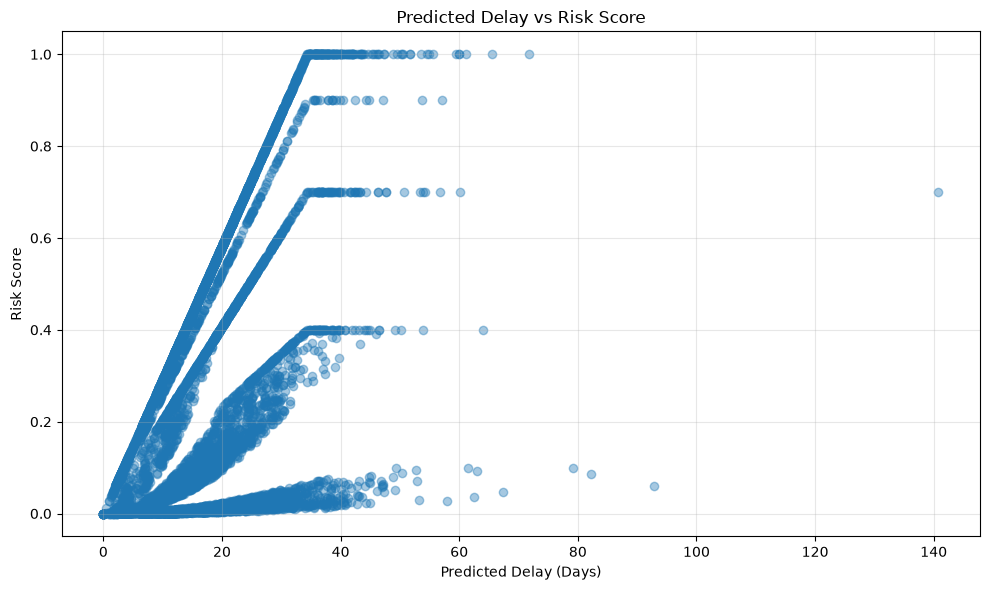

In [18]:
# Predicted delay vs risk score

plt.figure(figsize=(10, 6))

plt.scatter(
    risk_df["delay_prediction_days"],
    risk_df["risk_score"],
    alpha=0.4
)

plt.xlabel("Predicted Delay (Days)")
plt.ylabel("Risk Score")
plt.title("Predicted Delay vs Risk Score")
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [19]:
correlation = risk_df[
    ["delay_prediction_days", "risk_score"]
].corr()

print("Correlation between predicted delay and risk score:")
display(correlation)

Correlation between predicted delay and risk score:


,delay_prediction_days,risk_score
delay_prediction_days,1.000000,0.530405
risk_score,0.530405,1.000000


In [20]:
# Risk analysis by project

project_risk = (
    risk_df
    .groupby("project_id")
    .agg(
        activity_count=("activity_id", "count"),
        average_risk=("risk_score", "mean"),
        maximum_risk=("risk_score", "max"),
        average_delay=("delay_prediction_days", "mean"),
        total_predicted_delay=("delay_prediction_days", "sum")
    )
    .sort_values("average_risk", ascending=False)
)

print("Top 20 projects by average risk:")
display(project_risk.head(20))

Top 20 projects by average risk:


,activity_count,average_risk,maximum_risk,average_delay,total_predicted_delay
project_id,,,,,
P00037,93,0.447392,1.000000,23.467128,2182.442864
P00073,78,0.434348,1.000000,22.691424,1769.931092
P00072,61,0.432708,1.000000,22.024106,1343.470493
P00066,67,0.404122,1.000000,24.000528,1608.035349
P00078,62,0.386561,1.000000,25.297766,1568.461468
P00097,75,0.383345,1.000000,19.298172,1447.362913
P00005,83,0.377003,1.000000,19.859948,1648.375650
P00006,77,0.366159,1.000000,22.805649,1756.034990
P00033,67,0.360646,1.000000,17.626426,1180.970514


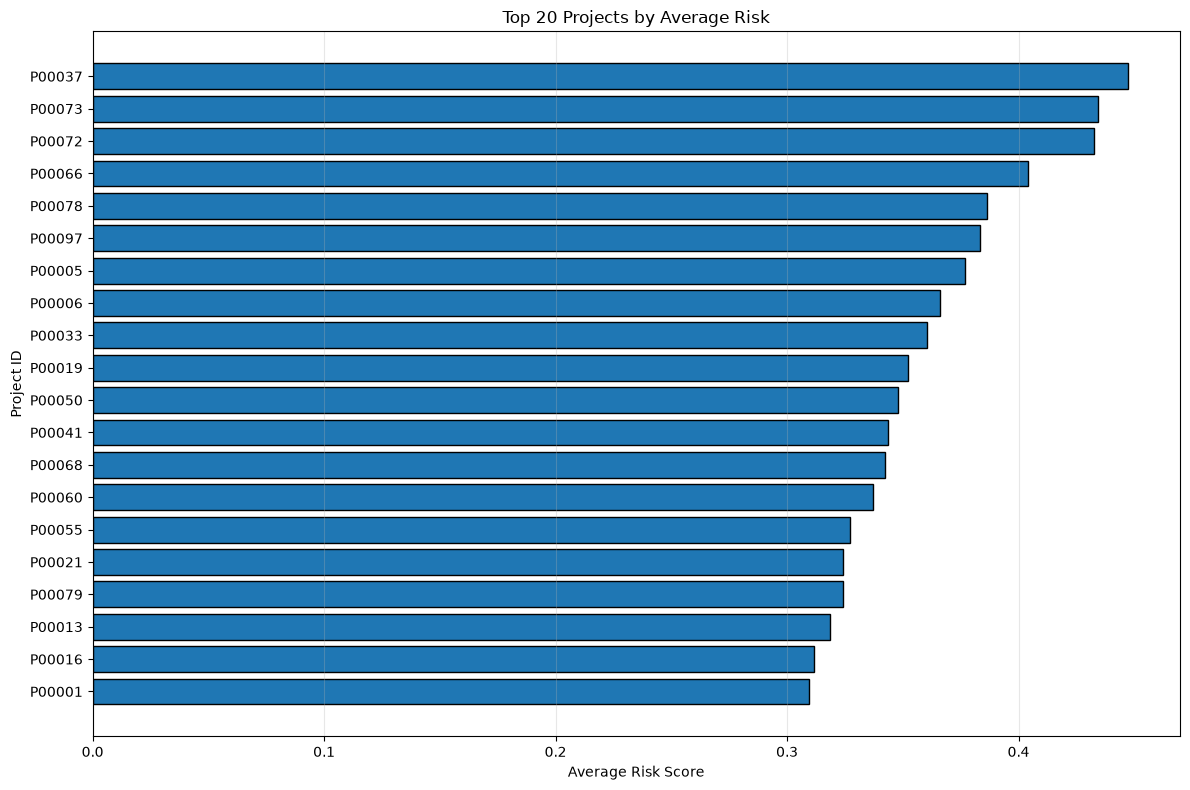

In [21]:
top_projects = (
    project_risk
    .head(20)
    .sort_values("average_risk")
)

plt.figure(figsize=(12, 8))

plt.barh(
    top_projects.index,
    top_projects["average_risk"],
    edgecolor="black"
)

plt.xlabel("Average Risk Score")
plt.ylabel("Project ID")
plt.title("Top 20 Projects by Average Risk")
plt.grid(axis="x", alpha=0.3)

plt.tight_layout()
plt.show()

In [22]:
top_delay_projects = (
    project_risk
    .sort_values("total_predicted_delay", ascending=False)
    .head(10)
)

print("Top 10 projects by total predicted delay:")
display(top_delay_projects)

Top 10 projects by total predicted delay:


,activity_count,average_risk,maximum_risk,average_delay,total_predicted_delay
project_id,,,,,
P00096,171,0.188658,0.828508,14.454776,2471.766681
P00039,148,0.172588,0.933731,15.720149,2326.582066
P00009,159,0.238203,1.000000,14.411864,2291.486445
P00003,107,0.207946,1.000000,21.028446,2250.043673
P00037,93,0.447392,1.000000,23.467128,2182.442864
P00091,142,0.203724,1.000000,15.349692,2179.656208
P00024,102,0.287496,1.000000,20.691305,2110.513099
P00089,126,0.168985,1.000000,16.624942,2094.742630
P00063,115,0.282242,1.000000,18.060736,2076.984669


In [23]:
# Risk analysis by resource type

resource_risk = (
    risk_df
    .groupby("resource_type")
    .agg(
        activity_count=("activity_id", "count"),
        average_risk=("risk_score", "mean"),
        maximum_risk=("risk_score", "max"),
        average_delay=("delay_prediction_days", "mean")
    )
    .sort_values("average_risk", ascending=False)
)

display(resource_risk)

,activity_count,average_risk,maximum_risk,average_delay
resource_type,,,,
information,186,0.468706,1.0,17.719170
management,94,0.463233,1.0,18.731957
equipment,1256,0.345164,1.0,17.401407
labour,7743,0.227758,1.0,16.989648


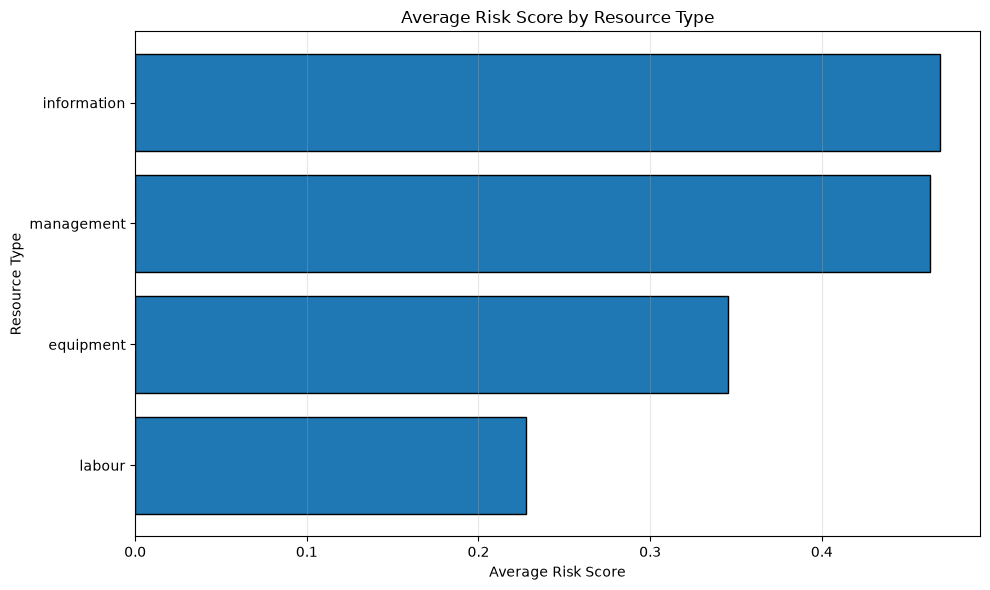

In [24]:
resource_plot = resource_risk.sort_values("average_risk")

plt.figure(figsize=(10, 6))

plt.barh(
    resource_plot.index.astype(str),
    resource_plot["average_risk"],
    edgecolor="black"
)

plt.xlabel("Average Risk Score")
plt.ylabel("Resource Type")
plt.title("Average Risk Score by Resource Type")
plt.grid(axis="x", alpha=0.3)

plt.tight_layout()
plt.show()

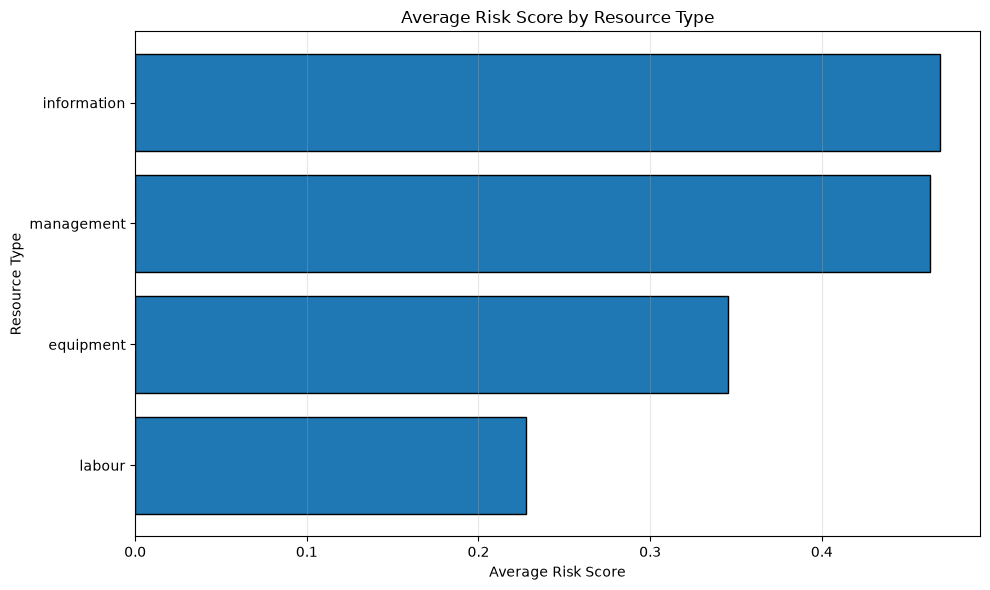

In [25]:
resource_plot = resource_risk.sort_values("average_risk")

plt.figure(figsize=(10, 6))

plt.barh(
    resource_plot.index.astype(str),
    resource_plot["average_risk"],
    edgecolor="black"
)

plt.xlabel("Average Risk Score")
plt.ylabel("Resource Type")
plt.title("Average Risk Score by Resource Type")
plt.grid(axis="x", alpha=0.3)

plt.tight_layout()
plt.show()

In [26]:
# High-risk activities by construction phase

high_risk_activities = risk_df[
    risk_df["risk_score"] > high_risk_threshold
]

high_risk_by_phase = (
    high_risk_activities
    .groupby("phase")
    .size()
    .sort_values(ascending=False)
)

print("High-risk activities by construction phase:")
display(high_risk_by_phase.to_frame("High-Risk Activity Count"))

High-risk activities by construction phase:


,High-Risk Activity Count
phase,
Structural Frame,400
Foundation,289
MEP,273
Finishing,269
Earthwork,234
Masonry,216
Preconstruction,197
Site Preparation,182
Commissioning,138


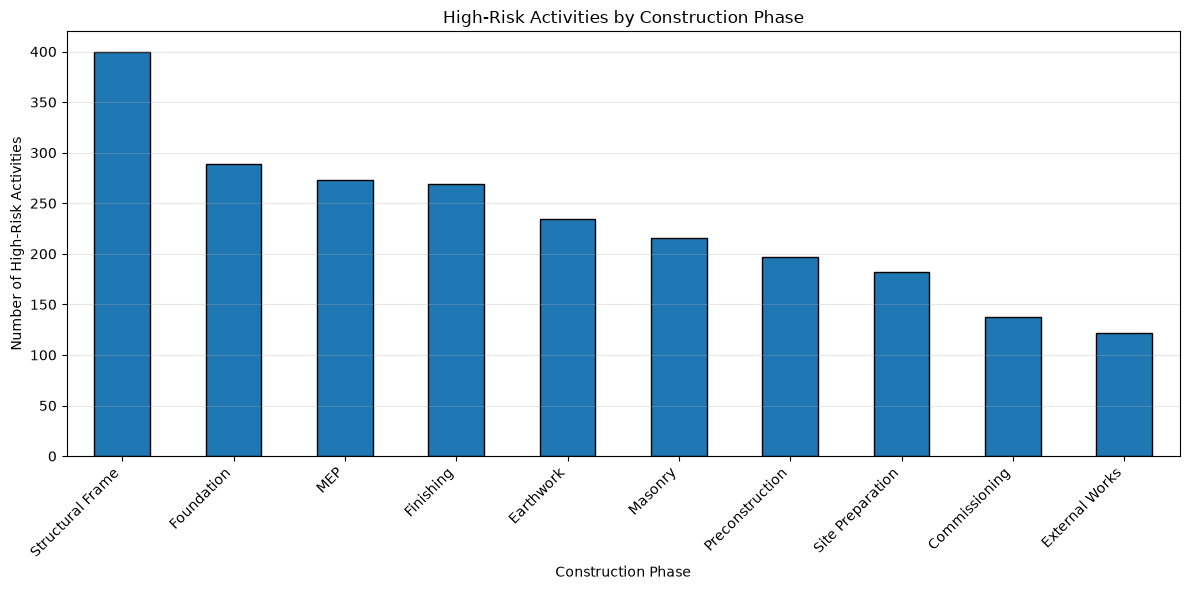

In [27]:
plt.figure(figsize=(12, 6))

high_risk_by_phase.plot(
    kind="bar",
    edgecolor="black"
)

plt.xlabel("Construction Phase")
plt.ylabel("Number of High-Risk Activities")
plt.title("High-Risk Activities by Construction Phase")
plt.xticks(rotation=45, ha="right")
plt.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

In [28]:
# ============================================================
# FINAL RISK ANALYSIS SUMMARY
# ============================================================

total_activities = len(risk_df)

mean_risk = risk_df["risk_score"].mean()
median_risk = risk_df["risk_score"].median()
max_risk = risk_df["risk_score"].max()

high_risk_count = (
    risk_df["risk_score"] > high_risk_threshold
).sum()

critical_risk_count = (
    risk_df["risk_score"] > critical_risk_threshold
).sum()

critical_path_count = (
    risk_df["computed_critical"] == 1
).sum()

critical_path_mean_risk = risk_df.loc[
    risk_df["computed_critical"] == 1,
    "risk_score"
].mean()

non_critical_mean_risk = risk_df.loc[
    risk_df["computed_critical"] == 0,
    "risk_score"
].mean()

mean_predicted_delay = risk_df[
    "delay_prediction_days"
].mean()

max_predicted_delay = risk_df[
    "delay_prediction_days"
].max()

print("=" * 60)
print("FINAL RISK ANALYSIS SUMMARY")
print("=" * 60)

print(f"Total activities analyzed       : {total_activities}")
print(f"Mean risk score                : {mean_risk:.4f}")
print(f"Median risk score              : {median_risk:.4f}")
print(f"Maximum risk score             : {max_risk:.4f}")

print()
print(f"High-risk activities           : {high_risk_count}")
print(f"Critical-risk activities       : {critical_risk_count}")

print()
print(f"Critical-path activities       : {critical_path_count}")
print(f"Critical-path mean risk        : {critical_path_mean_risk:.4f}")
print(f"Non-critical-path mean risk    : {non_critical_mean_risk:.4f}")

print()
print(f"Mean predicted delay           : {mean_predicted_delay:.2f} days")
print(f"Maximum predicted delay        : {max_predicted_delay:.2f} days")

print("=" * 60)

FINAL RISK ANALYSIS SUMMARY
Total activities analyzed       : 9279
Mean risk score                : 0.2509
Median risk score              : 0.1502
Maximum risk score             : 1.0000

High-risk activities           : 2320
Critical-risk activities       : 464

Critical-path activities       : 3153
Critical-path mean risk        : 0.4934
Non-critical-path mean risk    : 0.1260

Mean predicted delay           : 17.08 days
Maximum predicted delay        : 140.76 days


In [29]:
# Save the enriched risk analysis dataset

output_path = "../data/processed/risk_scores_analyzed.csv"

risk_df.to_csv(
    output_path,
    index=False
)

print(f"Analysis dataset saved to: {output_path}")
print(f"Rows: {len(risk_df)}")
print(f"Columns: {len(risk_df.columns)}")

Analysis dataset saved to: ../data/processed/risk_scores_analyzed.csv
Rows: 9279
Columns: 19
